In [ ]:
!pip install networkx matplotlib

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

In [ ]:
    def get_path(previous, target):
      path = []
    while target is not None:
        path.insert(0, target)
        target = previous[target]
    return path

In [ ]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

Jarak dari A ke Z: 14
Jalur: A -B -D -E -Z


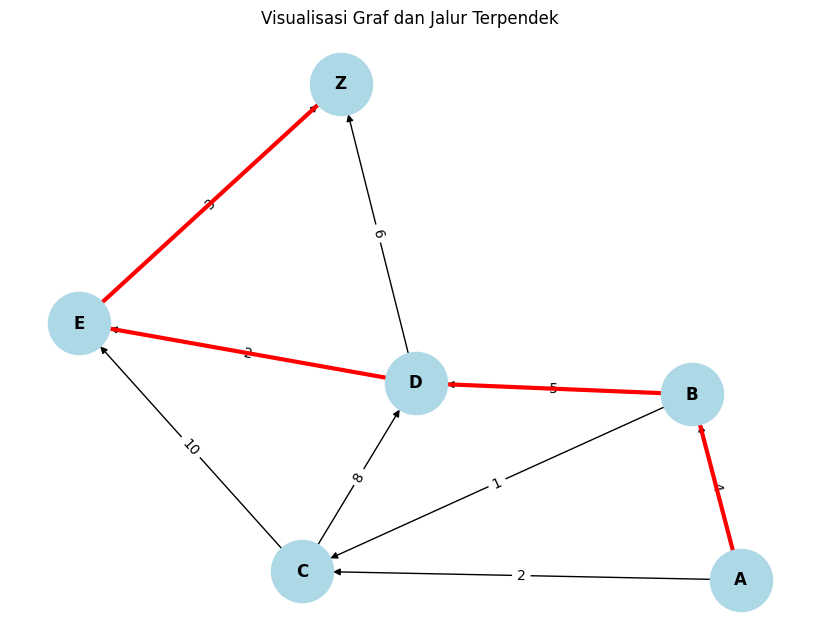

In [7]:
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node   = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -'.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

Jarak A ke Z (graf siklus): 14
Jalur: A -> B -> D -> E -> Z


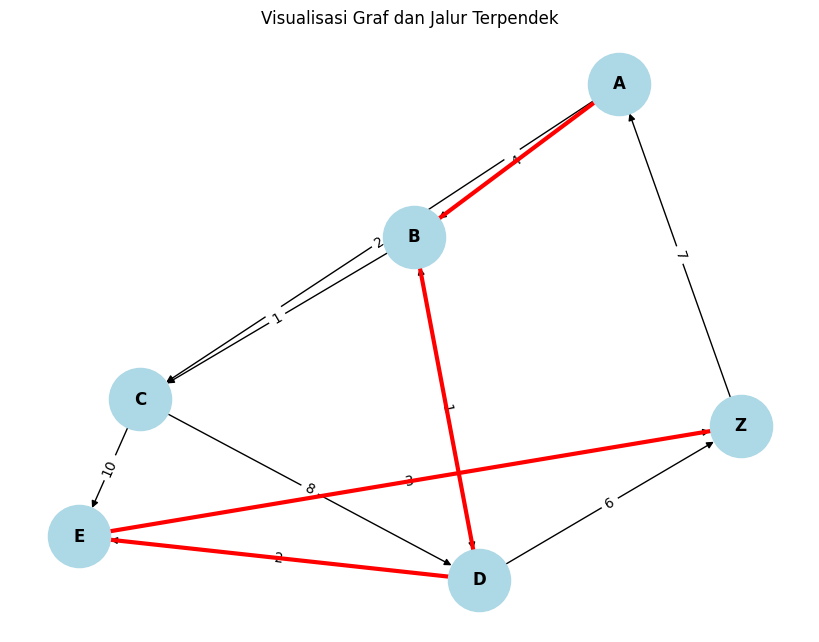

In [8]:
# Graf dengan siklus
graph_cycle = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6, 'B': 1},   # siklus D -> B
    'E': {'Z': 3},
    'Z': {'A': 7}                      # siklus Z -> A
}

distances_c, previous_c = dijkstra_with_paths(graph_cycle, 'A')
path_c = get_path(previous_c, 'Z')
print(f'Jarak A ke Z (graf siklus): {distances_c["Z"]}')
print(f'Jalur: {" -> ".join(path_c)}')
visualize_graph(graph_cycle, path=path_c)

Jarak A ke Z (dengan simpul F): 8
Jalur: A -> F -> D -> E -> Z


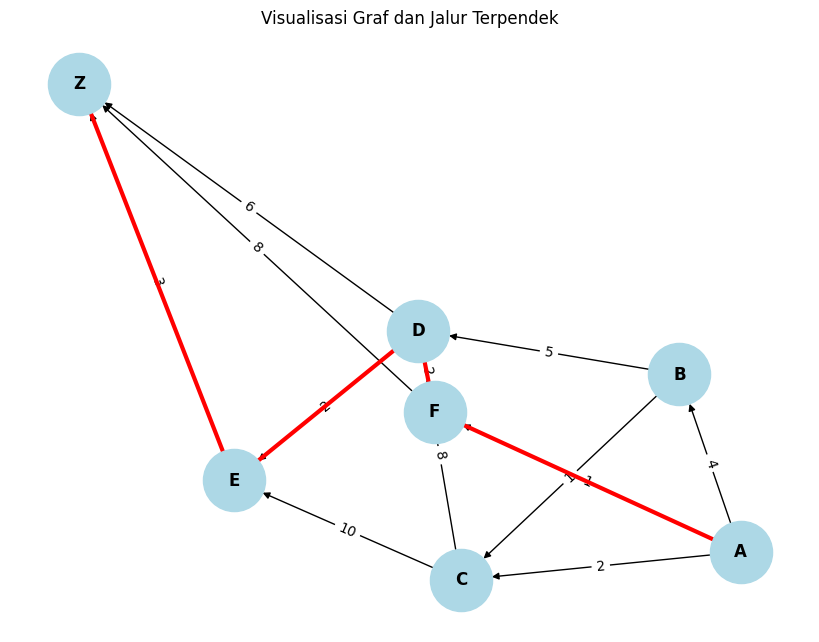

In [9]:
# Graf dengan simpul baru 'F'
graph_new = {
    'A': {'B': 4, 'C': 2, 'F': 1},   # A terhubung ke F dengan bobot 1
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'F': {'D': 2, 'Z': 8},            # simpul baru F
    'Z': {}
}

distances_n, previous_n = dijkstra_with_paths(graph_new, 'A')
path_n = get_path(previous_n, 'Z')
print(f'Jarak A ke Z (dengan simpul F): {distances_n["Z"]}')
print(f'Jalur: {" -> ".join(path_n)}')
visualize_graph(graph_new, path=path_n)

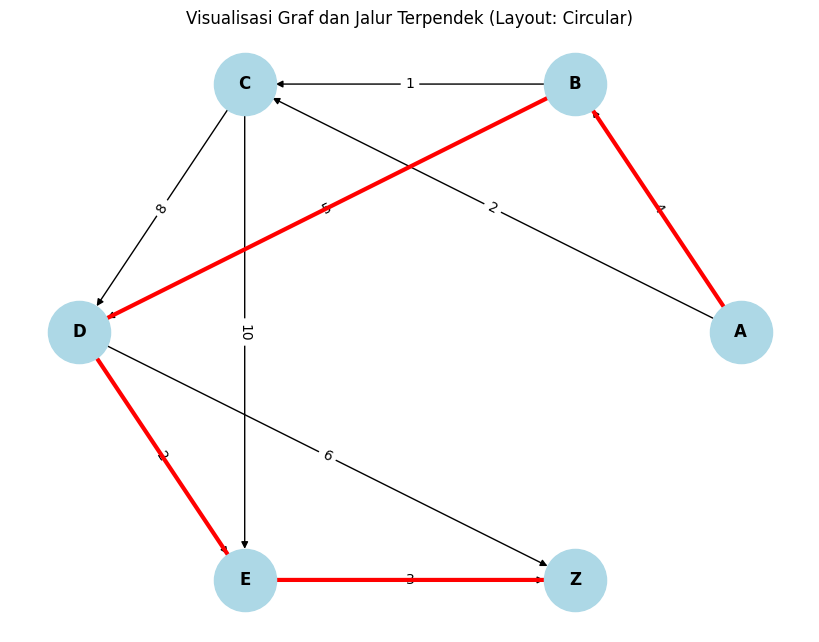

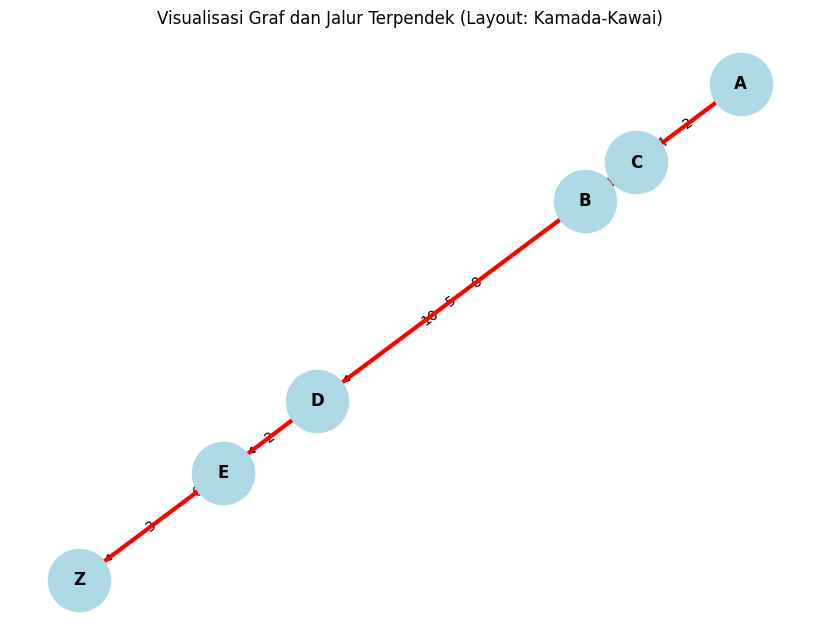

In [10]:
# Menggunakan circular layout
def visualize_graph_custom_layout(graph, path=None, layout='spring'):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Pilih layout
    if layout == 'circular':
        pos = nx.circular_layout(G)
        title = 'Layout: Circular'
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
        title = 'Layout: Kamada-Kawai'
    else:
        pos = nx.spring_layout(G)
        title = 'Layout: Spring (Default)'

    edge_labels = nx.get_edge_attributes(G, 'weight')
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color='red', width=3)

    plt.title(f'Visualisasi Graf dan Jalur Terpendek ({title})')
    plt.axis('off')
    plt.show()

# Jalankan dengan berbagai layout
distances, previous = dijkstra_with_paths(graph, 'A')
path = get_path(previous, 'Z')
visualize_graph_custom_layout(graph, path=path, layout='circular')
visualize_graph_custom_layout(graph, path=path, layout='kamada_kawai')